In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 3]
from tqdm import tqdm

from env import Simulator
from LogisticRegression import ThompsonSampling
from utils import sigmoid, softmax, run_experiment

# Linear reward

The reward score is linear in the context-action feature (as in the original paper):

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x,a])}$$

Important to note is that a noisy version of this formula implemented, i.e.,
$Y_{observed} = Ber\{p\}$, where $p = \frac{1}{1 + exp(-w_*^T \cdot [x,a] + \varepsilon)}$

In [2]:
np.random.seed(123)
k = 20
n = 10000

linear_env = Simulator(k=k, linear=True)
X = linear_env.generate_batch(n)
A = np.random.choice(range(k), size=n)
Y, true_scores = linear_env.generate_reward(A)

optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = softmax(true_scores).sum(axis=0)

The plot below represents that there single optimal action for a batch of 10000 contexts. This is due to linearity of the underlying reward score with respect to x,a feature. Despite this, the suboptimal gap is quite small and the second best action is relatively close to the best one. 

This is important to note, because a policy observes noisy realization of these scores and suboptimal arms might appear optimal when noise is added.

Note: the scale of the normalized scores (orange) doesn't matter here.

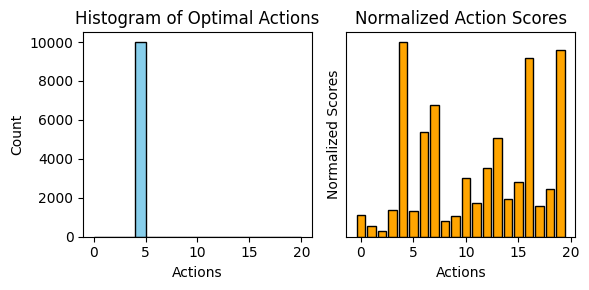

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

## Run single experiment 

Running an experiment for Thompson sampling policy, we track 3 values:
- Mean squared error between learned params $\hat{w}$ and true params $w_*$
- Mean squared error between learned scores $\hat{p}$ and true scores $p_*$
- variance $q$ of the posterior distribution

In [4]:
batch_size = 32
n_iter = 10000

d = linear_env.d_x + linear_env.d_a
policy = ThompsonSampling(d, regularization_strength=0.1)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment(linear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params 0.7254, mse scores: 60.9398, variance: 10.0000
      1/  10000 - mse params 0.6124, mse scores: 18.2492, variance: 4.0933
      2/  10000 - mse params 0.1386, mse scores: 6.4505, variance: 1.4638
      3/  10000 - mse params 0.4634, mse scores: 5.5069, variance: 1.0957
      4/  10000 - mse params 0.1876, mse scores: 12.7073, variance: 0.8204
      5/  10000 - mse params 0.1175, mse scores: 7.2136, variance: 0.6026
      6/  10000 - mse params 0.0234, mse scores: 9.5512, variance: 0.5049
      7/  10000 - mse params 0.1215, mse scores: 6.6331, variance: 0.4449
      8/  10000 - mse params 0.1142, mse scores: 3.4816, variance: 0.4001
      9/  10000 - mse params 0.1115, mse scores: 2.4445, variance: 0.3452
     10/  10000 - mse params 0.0415, mse scores: 2.4009, variance: 0.3144
     11/  10000 - mse params 0.0743, mse scores: 9.7502, variance: 0.2919
     12/  10000 - mse params 0.0644, mse scores: 3.3468, variance: 0.2719
     13/  10000 - mse params 0.064

We also plot the distribution of chosen and optimal actions and the regret of Thompson sampling compared to random policy.

Note: Graphs 2 and 3 represent the same regret, with graph 3 is a "shorter" version illustrating the comparison between Thompson sampling and random policies over the first 100 iterations

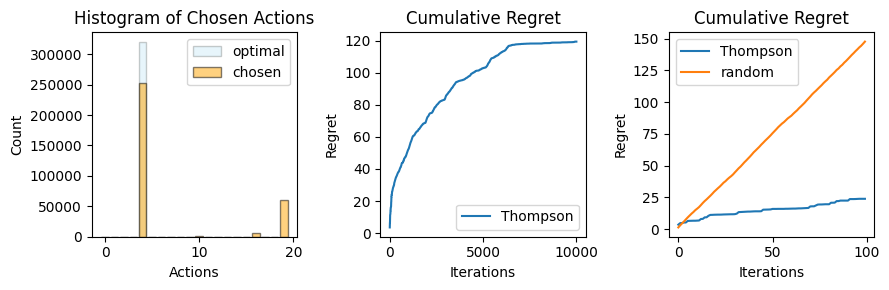

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(logreg_regret).cumsum(), label='Thompson')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

# the same plot, but with random performance
axes[2].plot(np.array(logreg_regret)[:100].cumsum(), label='Thompson')
axes[2].plot(np.array(random_regret)[:100].cumsum(), label='random')
axes[2].set_title('Cumulative Regret')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Regret')
axes[2].legend()

plt.tight_layout()
plt.show()

## Average over multiple runs

Here we run several experiments to ensure that Thompson sampling consistently converges to the optimum.

Note: Graphs 1 and 2 represent the same regret, with graph 2 is a "shorter" version illustrating the comparison between Thompson sampling and random policies over the first 100 iterations.

In [6]:
np.random.seed(123)

k = 20
batch_size = 32
n_runs = 5
n_iter = 10000
n_regret_random = []
n_regret_logreg = []

for i in tqdm(range(n_runs)):
    linear_env = Simulator(k=k, linear=True)
    d = linear_env.d_x + linear_env.d_a
    policy = ThompsonSampling(d, regularization_strength=0.1)
    
    chosen_actions, _, logreg_regret, random_regret = run_experiment(linear_env, policy)
    n_regret_logreg.append(logreg_regret)
    n_regret_random.append(random_regret)

100%|██████████| 5/5 [02:13<00:00, 26.69s/it]


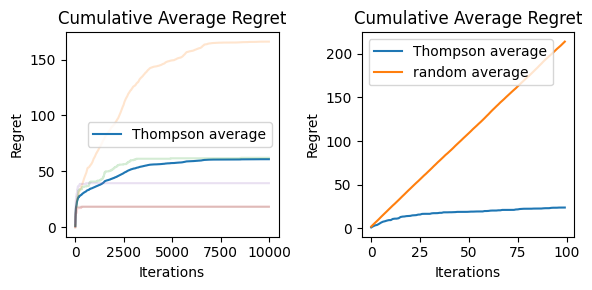

In [7]:
n_regret_logreg = np.array(n_regret_logreg)
n_regret_random = np.array(n_regret_random)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].plot(n_regret_logreg.mean(axis=0).cumsum(), label='Thompson average')
for i in range(n_runs):
    axes[0].plot(n_regret_logreg[i].cumsum(), alpha=0.2)
axes[0].set_title('Cumulative Average Regret')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Regret')
axes[0].legend()

# the same plot, but with random performance
axes[1].plot(n_regret_logreg.mean(axis=0)[:100].cumsum(), label='Thompson average')
axes[1].plot(n_regret_random.mean(axis=0)[:100].cumsum(), label='random average')
axes[1].set_title('Cumulative Average Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

plt.tight_layout()
plt.show()

# Nonlinear reward

To ensure the optimal action varies with context features, we integrate the context features $x$ with the action features $a$. Instead of fixed features $a$, define $a(x)$ so that action features dynamically interact with $x$: $a(x) = a + L(a) \cdot x$, where $L$ is the context-action weight vector.

So, in this setting, the reward score is linear in the $x, a(x)$ features:

$$P(y|x,a) = \frac{1}{1 + exp(-w_*^T \cdot [x, a(x)])}.$$

Such a reward structure represents a set of linear functions for a given $a$, but the overall reward structure, across different actions $a$, is nonlinear. Intuitively, Regularized Logistic regression should have trouble learning such rewards because weights $L(a)$ are never presented explicitly, and the parameterization of the policy shouldn't be able to capture these dependencies.

In [8]:
np.random.seed(123)
k = 20
n = 10000

nonlinear_env = Simulator(k=k, linear=False)
X = nonlinear_env.generate_batch(n)
A = np.random.choice(range(k), size=n)
Y, true_scores = nonlinear_env.generate_reward(A)

optimal_actions = true_scores.argmax(axis=1)
normalized_actions_scores = sigmoid(true_scores).sum(axis=0)

In the plot below, normalized scores (orange) show that over the whole population, there is an optimal action - action 4; nevertheless, optimal actions (blue) show that optimality given context $x$ varies.

Note: the scale of the normalized scores (orange) doesn't matter here.

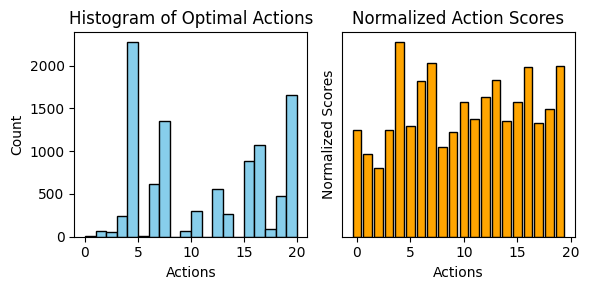

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].hist(optimal_actions, bins=range(0, k + 1), color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Optimal Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')

axes[1].bar(range(k), normalized_actions_scores, color='orange', edgecolor='black')
axes[1].set_title('Normalized Action Scores')
axes[1].set_xlabel('Actions')
axes[1].set_ylabel('Normalized Scores')
axes[1].get_yaxis().set_ticks([])

plt.tight_layout()
plt.show()

## Run single experiment

In [10]:
batch_size = 32
n_iter = 10000

d = nonlinear_env.d_x + nonlinear_env.d_a
policy = ThompsonSampling(d, regularization_strength=0.1)

chosen_actions, optimal_actions, logreg_regret, random_regret = run_experiment(nonlinear_env, policy, n_iter, batch_size, verbose=True)

      0/  10000 - mse params 0.7254, mse scores: 44.2065, variance: 10.0000
      1/  10000 - mse params 0.9728, mse scores: 60.2899, variance: 4.3813
      2/  10000 - mse params 2.0884, mse scores: 70.7247, variance: 3.2755
      3/  10000 - mse params 1.8257, mse scores: 79.3414, variance: 2.4875
      4/  10000 - mse params 0.4477, mse scores: 20.3229, variance: 1.4967
      5/  10000 - mse params 0.4599, mse scores: 10.3335, variance: 1.1175
      6/  10000 - mse params 0.2666, mse scores: 13.1460, variance: 0.8513
      7/  10000 - mse params 0.8920, mse scores: 6.6744, variance: 0.7351
      8/  10000 - mse params 0.7931, mse scores: 15.8747, variance: 0.5786
      9/  10000 - mse params 0.2412, mse scores: 7.4057, variance: 0.4875
     10/  10000 - mse params 0.0561, mse scores: 5.2410, variance: 0.4282
     11/  10000 - mse params 0.1999, mse scores: 8.7735, variance: 0.3944
     12/  10000 - mse params 0.2386, mse scores: 7.6774, variance: 0.3355
     13/  10000 - mse params 

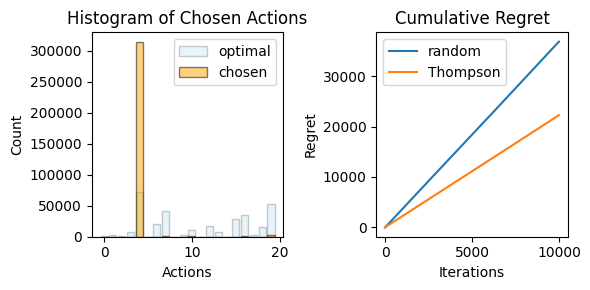

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=False)
axes[0].bar(range(k), optimal_actions, alpha=0.2, color='skyblue', edgecolor='black', label='optimal')
axes[0].bar(range(k), chosen_actions, alpha=0.5, color='orange', edgecolor='black', label='chosen')
axes[0].set_title('Histogram of Chosen Actions')
axes[0].set_xlabel('Actions')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(np.array(random_regret).cumsum(), label='random')
axes[1].plot(np.array(logreg_regret).cumsum(), label='Thompson')
axes[1].set_title('Cumulative Regret')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Regret')
axes[1].legend()

plt.tight_layout()
plt.show()

In the case of nonlinear reward, Thompson sampling learned the best average action and struggled to adapt to different contexts. This is expected because the learned parameters $\hat{w}$ are inherently less expressive than the parameter of the true data-generating process $w_*$ and $L$.